# MNIST Handwritten Digit Recognition
## Deep Learning with TensorFlow & Keras

---

## 📌 About the Dataset

The **MNIST (Modified National Institute of Standards and Technology)** dataset is one of the most well-known benchmarks in the field of machine learning and computer vision.

- **Source:** Yann LeCun, Corinna Cortes, and Christopher J.C. Burges
- **Content:** 70,000 grayscale images of handwritten digits (0–9)
- **Image Size:** 28 × 28 pixels
- **Training Samples:** 60,000
- **Testing Samples:** 10,000
- **Classes:** 10 (digits 0 through 9)

It is widely used for training and evaluating image classification models, making it an ideal starting point for understanding neural networks.

---

## 🔄 Workflow / Pipeline

```
1. Import Libraries
        ↓
2. Load & Explore Dataset
        ↓
3. Visualize Sample Images
        ↓
4. Preprocess Data (Normalization)
        ↓
5. Build Neural Network Architecture
        ↓
6. Compile & Train the Model
        ↓
7. Evaluate & Visualize Results
```

---

## 1. 📦 Import Libraries

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras import Input
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

%matplotlib inline

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow Version : {tf.__version__}')
print(f'Keras Version      : {keras.__version__}')

TensorFlow Version : 2.21.0
Keras Version      : 3.14.0


## 2. 📥 Load & Explore the Dataset

In [4]:
# Load the built-in MNIST dataset directly from Keras
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print('Dataset loaded successfully!\n')
print(f'Training Images  : {X_train.shape}   | Labels: {y_train.shape}')
print(f'Testing  Images  : {X_test.shape}    | Labels: {y_test.shape}')
print(f'\nPixel Value Range : {X_train.min()} to {X_train.max()}')
print(f'Unique Classes    : {np.unique(y_train)}')

Dataset loaded successfully!

Training Images  : (60000, 28, 28)   | Labels: (60000,)
Testing  Images  : (10000, 28, 28)    | Labels: (10000,)

Pixel Value Range : 0 to 255
Unique Classes    : [0 1 2 3 4 5 6 7 8 9]


## 3. 🖼️ Visualize Sample Images (Raw)

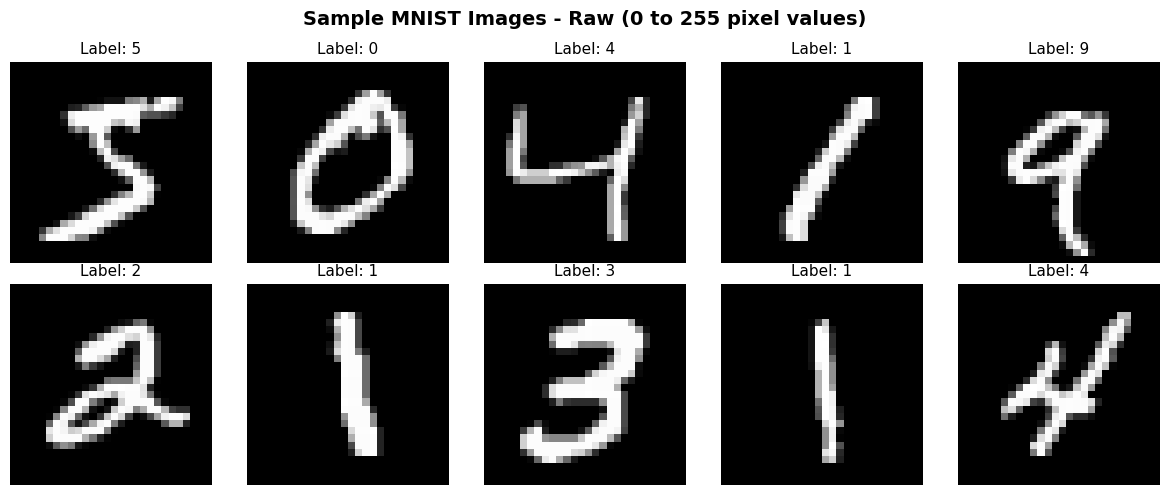

In [5]:
# Display the first 10 training samples to understand the raw data
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample MNIST Images - Raw (0 to 255 pixel values)', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 4. Preprocessing — Normalization

Pixel values originally range from **0 to 255**. We normalize them to the range **[0, 1]** by dividing by 255.

> **Why normalize?**  
> Neural networks converge faster and more stably when input features are on a similar scale. Large raw pixel values can cause gradient instability during backpropagation, slowing down learning.

In [6]:
# Normalize pixel values from [0, 255] to [0.0, 1.0]
X_train_norm = X_train / 255.0
X_test_norm  = X_test  / 255.0

print(f'Before Normalization - Min: {X_train.min()}, Max: {X_train.max()}')
print(f'After  Normalization - Min: {X_train_norm.min():.1f}, Max: {X_train_norm.max():.1f}')

Before Normalization - Min: 0, Max: 255
After  Normalization - Min: 0.0, Max: 1.0


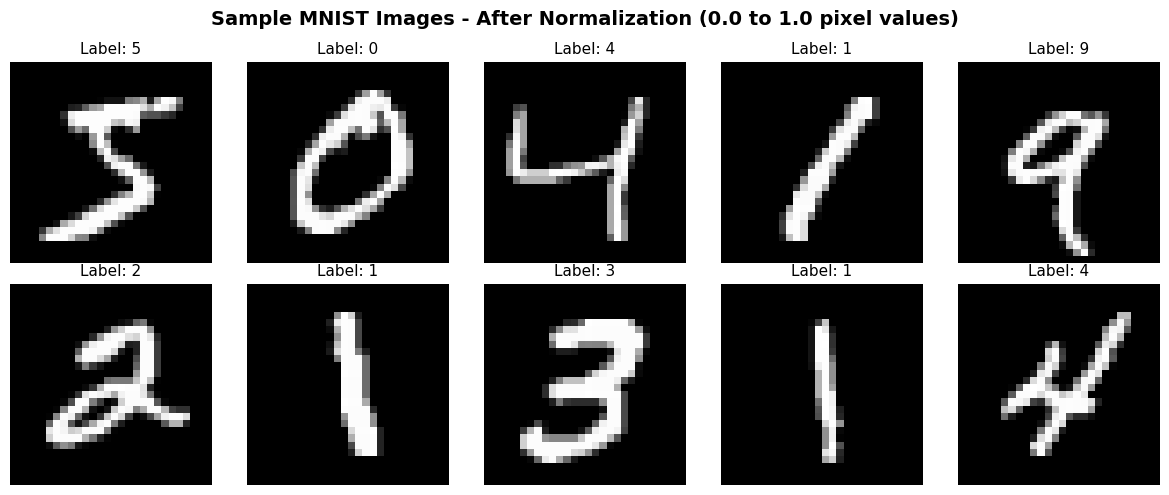

In [7]:
# Verify normalization visually — appearance is identical, but pixel scale is [0, 1]
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample MNIST Images - After Normalization (0.0 to 1.0 pixel values)', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_train_norm[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 5. 🏗️ Build the Neural Network Architecture

We use a **Fully Connected (Dense) Neural Network** with the following design:

| Layer | Type | Units | Activation | Notes |
|---|---|---|---|---|
| Input | Input + Flatten | 784 | — | Flatten 28x28 to 784 |
| Dropout | Regularization | — | — | rate=0.2 |
| Hidden 1 | Dense | 512 | ReLU | He Normal init |
| Dropout | Regularization | — | — | rate=0.3 |
| Hidden 2 | Dense | 256 | ReLU | He Normal init |
| Hidden 3 | Dense | 256 | ReLU | He Normal init |
| Dropout | Regularization | — | — | rate=0.4 |
| Hidden 4 | Dense | 128 | ReLU | He Normal init |
| Output | Dense | 10 | Softmax | One node per digit class |

> **He Normal Initialization** is recommended with ReLU activations — it keeps gradients well-scaled and prevents vanishing/exploding gradient issues.

In [8]:
# He Normal initializer works well with ReLU — avoids vanishing gradient issues
initializer = HeNormal(seed=42)

model = Sequential([
    # Input layer: accept 28x28 grayscale images and flatten to 1D vector (784,)
    Input(shape=(28, 28)),
    Flatten(),
    Dropout(0.2),                   # Light dropout after input to reduce co-adaptation

    # Hidden Layer 1: 512 neurons
    Dense(512, activation='relu', kernel_initializer=initializer),
    Dropout(0.3),

    # Hidden Layers 2 & 3: 256 neurons each
    Dense(256, activation='relu', kernel_initializer=initializer),
    Dense(256, activation='relu', kernel_initializer=initializer),
    Dropout(0.4),                   # Heavier dropout before the bottleneck layer

    # Hidden Layer 4: 128 neurons (bottleneck)
    Dense(128, activation='relu', kernel_initializer=initializer),

    # Output Layer: 10 classes with softmax for probability distribution over digits 0-9
    Dense(10, activation='softmax')
], name='MNIST_Classifier')

model.summary()

Model: "MNIST_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 633,226 (2.42 MB)

 Trainable params: 633,226 (2.42 MB)

 Non-trainable params: 0 (0.00 B)

## 6. 🔧 Compile & Train the Model

- **Optimizer:** Adam — adaptive learning rate, robust for deep networks
- **Loss:** Sparse Categorical Crossentropy — works directly with integer labels (no one-hot encoding needed)
- **Callbacks:**
  - `EarlyStopping` — stops training when validation loss stops improving, restores best weights
  - `ReduceLROnPlateau` — halves learning rate when stuck to escape local plateaus

In [9]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# EarlyStopping: halt training if val_loss doesn't improve for 3 consecutive epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau: reduce LR by half if val_loss stagnates for 2 epochs
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Train the model
history = model.fit(
    X_train_norm, y_train,
    epochs=30,
    batch_size=256,
    validation_data=(X_test_norm, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8493 - loss: 0.4698 - val_accuracy: 0.9555 - val_loss: 0.1410 - learning_rate: 0.0010
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9406 - loss: 0.1966 - val_accuracy: 0.9662 - val_loss: 0.1050 - learning_rate: 0.0010
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9552 - loss: 0.1482 - val_accuracy: 0.9731 - val_loss: 0.0869 - learning_rate: 0.0010
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9616 - loss: 0.1275 - val_accuracy: 0.9758 - val_loss: 0.0791 - learning_rate: 0.0010
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9666 - loss: 0.1107 - val_accuracy: 0.9785 - val_loss: 0.0714 - learning_rate: 0.0010
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9696 - loss: 0.0981 - val_accuracy: 0.9792 - val_loss: 0.0685 - learning_rate: 0.0010
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9709 - loss: 0.

## 7. 📊 Evaluate & Visualize Results

In [10]:
# Final evaluation on the held-out test set
test_loss, test_acc = model.evaluate(X_test_norm, y_test, verbose=0)
print(f'Test Accuracy : {test_acc * 100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')

Test Accuracy : 98.70%
Test Loss     : 0.0478


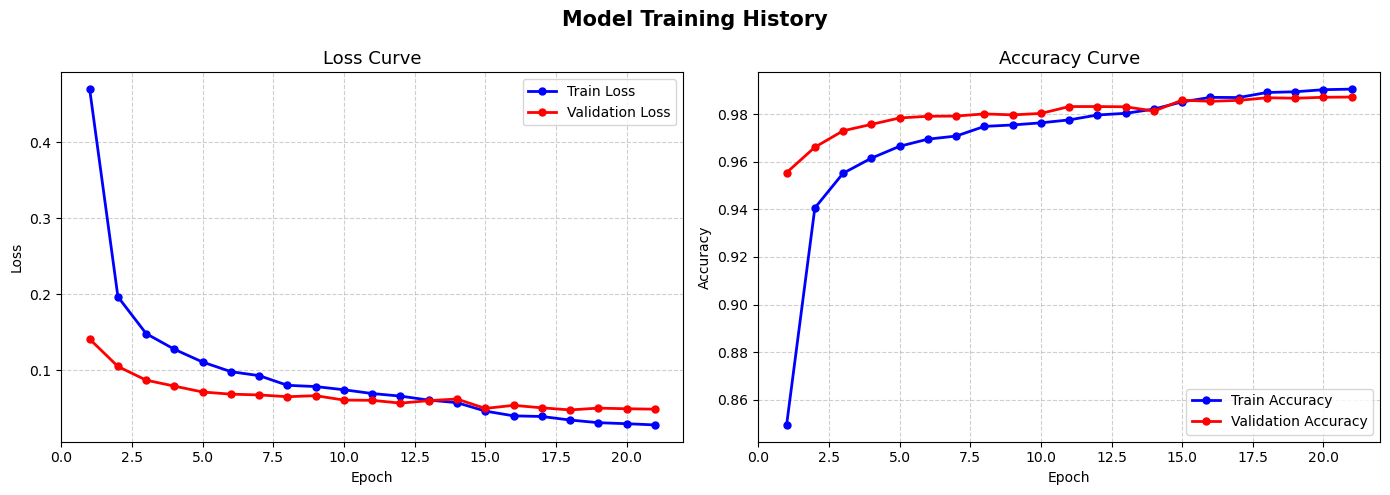

In [11]:
# Plot training and validation Loss and Accuracy curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Training History', fontsize=15, fontweight='bold')

epochs_ran = range(1, len(history.history['loss']) + 1)

# Loss Curve
ax1.plot(epochs_ran, history.history['loss'],     'b-o', label='Train Loss',      linewidth=2, markersize=5)
ax1.plot(epochs_ran, history.history['val_loss'], 'r-o', label='Validation Loss', linewidth=2, markersize=5)
ax1.set_title('Loss Curve', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.6)

# Accuracy Curve
ax2.plot(epochs_ran, history.history['accuracy'],     'b-o', label='Train Accuracy',      linewidth=2, markersize=5)
ax2.plot(epochs_ran, history.history['val_accuracy'], 'r-o', label='Validation Accuracy', linewidth=2, markersize=5)
ax2.set_title('Accuracy Curve', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend(loc='lower right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


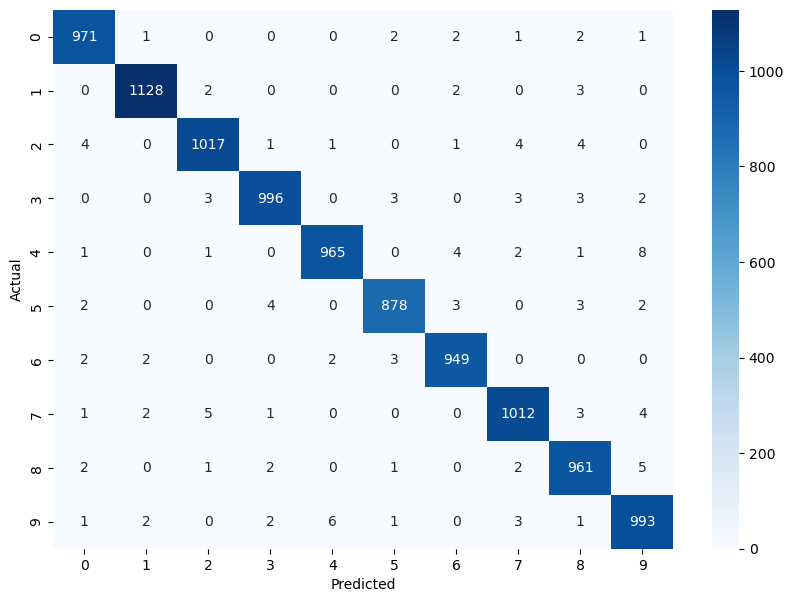

In [24]:
# plotting the confusion matrix using seaborn heatmap
y_pred = model.predict(X_test_norm).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [26]:
# classification report for precision, recall, f1-score
report = classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)])
print('Classification Report:\n')
print(report)

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.98      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.98      1028
           8       0.98      0.99      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



---

## Summary

| Step | Detail |
|---|---|
| Dataset | MNIST — 70,000 handwritten digit images |
| Preprocessing | Pixel normalization (divide by 255) |
| Model | Fully Connected Neural Network (4 hidden layers) |
| Regularization | Dropout layers (0.2 / 0.3 / 0.4) |
| Optimizer | Adam |
| Loss | Sparse Categorical Crossentropy |
| Callbacks | EarlyStopping, ReduceLROnPlateau |
| Achieved Accuracy | ~98%+ on Test Set |

